<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# III. Materiais elásticos
## Lei de Hooke. Parte II

## Problema 2 <a name="PIII72"></a>

Numa placa plana sujeita à tracção e a um esforço de corte, foram obtidas num ponto uma tensão normal $\sigma_{xx} = $ 20 MPa e uma tensão de corte $\tau_{xy} = $ 15 MPa ($E = 200$ GPa, $\nu = 0.3$).

[a)](#A) Calcule o tensor das extensões, assumindo um material elástico, linear e isotrópico.

[b)](#B) Calcule as extensões principais.

[c)](#C) Calcule o tensor desviador e o tensor esférico das tensões.


## Resolução

### a) Calcule o tensor das extensões, assumindo um material elástico, linear e isotrópico.<a name="A"></a>
([enunciatum](#PIII72))

##### Da lei de Hooke para um material isotrópico.

Para um material isotrópico a lei de Hooke tridimensional vem expressa por:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{E}[(1+\nu)\sigma_{ij} - \nu\delta_{ij}\sigma_{kk}]
\end{equation*}

Em forma matricial a lei constitutiva linear elástica expressa em termos de módulo de Young e coeficiente de Poisson em estado plano de tensão ($\sigma_{31} = \sigma_{13} = \sigma_{32} = \sigma_{23} = \sigma_{33}$) vem:

\begin{equation*}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ 2\varepsilon_{12}
\end{bmatrix} = \frac{1}{E}
\begin{bmatrix}
1 & -\nu & 0 \\
-\nu & 1 & 0 \\
0 & 0 & 2(1+\nu) \\
\end{bmatrix}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \tau_{12}
\end{bmatrix}
\end{equation*}

com ainda,

\begin{equation*}
\varepsilon_{33} = -\frac{\nu}{E}(\sigma_{11} + \sigma_{22})
\end{equation*}

Em notação tensorial vem:

\begin{equation*}
\begin{bmatrix}
\varepsilon_{11} & \varepsilon_{12} \\
\varepsilon_{12} &  \varepsilon_{22}
\end{bmatrix} =
\frac{1+\nu}{E}
\begin{bmatrix}
\sigma_{11} & \tau_{12} \\
\tau_{12} &  \sigma_{22}
\end{bmatrix} -
\frac{\nu}{E}[I](\sigma_{11} + \sigma_{22})
\end{equation*}

O tensor das deformações 3D pode ser expresso pela seguinte matriz de deformações:

\begin{equation*}
\underline{\underline{\varepsilon}} \equiv \varepsilon_{ij} \equiv [\varepsilon] =
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \gamma_{zyy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{zyy}/2 & \varepsilon_{zz} \\
\end{bmatrix}
\end{equation*}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 18
rc('text', usetex=True)

def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ):
    return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sYZ,sYZ,sZZ]])

sxx, syy, txy = 20., 0., 15. # unid: MPa

tt0 = mtensoes(sxx,txy,0,syy,0,0)
print('matriz das tensões (estado plano de tensão) : \n',tt0,' [MPa]')

E, v = 200.*1e3, 0.3 
G = E/2/(1+v)
print('\nPropriedades do material: ---------------')
print('     E (MPa) = ',E)
print('           v = ',v)
print('     G (MPa) = ','{:.2f}'.format(G))

def S2D(E,v):
    return (1/E)*np.array([[1,-v,0],[-v,1,0],[0,0,2*(1+v)]])

def C2D(E,v):
    return (E/(1-v**2))*np.array([[1,v,0],[v,1,0],[0,0,(1-v)/2]])

def tens2D(s11,s22,s12):
    return np.array([s11,s22,s12])

def def2D(e11,e22,e12):
    return np.array([e11,e22,2*e12])

def def3D(e11,e12,e13,e22,e23,e33):
    return np.array([[e11,e12,e13],[e12,e22,e23],[e13,e23,e33]])

print('\nEstado de deformação:')
eps = np.dot(S2D(E,v),tens2D(sxx,syy,txy))
print('Eps  = ',eps)

def TensorEps(s11,s22,s12):
    return (1+v)/E*np.array([[s11,s12],[s12,s22]]) - (v/E)*np.eye(2)*(s11 + s22)

eps1 = TensorEps(sxx,syy,txy)
print('eps1 = \n',eps1)

print('\nComponentes da matriz das deformações:')
epsX = eps[0]
print('EpsX    = ','{:.1f}'.format(epsX*1e6),' micro-def')
epsY = eps[1]
print('EpsY    = ','{:.1f}'.format(epsY*1e6),' micro-def')
epsZ = -(v/E)*(sxx+syy)
print('EpsZ    = ','{:.1f}'.format(epsZ*1e6),' micro-def')
GammaXY = eps[2]
print('GammaXY = ','{:.1f}'.format(GammaXY*1e6),' micro-def')
EpsXY = GammaXY/2
print('EpsXY   = ','{:.1f}'.format(EpsXY*1e6),' micro-def')

D = def3D(epsX,EpsXY,0,epsY,0,epsZ)
print('\nTensor das deformações \n',D*1e6,'micro-def')

matriz das tensões (estado plano de tensão) : 
 [[20 15  0]
 [15  0  0]
 [ 0  0  0]]  [MPa]

Propriedades do material: ---------------
     E (MPa) =  200000.0
           v =  0.3
     G (MPa) =  76923.08

Estado de deformação:
Eps  =  [ 1.00e-04 -3.00e-05  1.95e-04]
eps1 = 
 [[ 1.00e-04  9.75e-05]
 [ 9.75e-05 -3.00e-05]]

Componentes da matriz das deformações:
EpsX    =  100.0  micro-def
EpsY    =  -30.0  micro-def
EpsZ    =  -30.0  micro-def
GammaXY =  195.0  micro-def
EpsXY   =  97.5  micro-def

Tensor das deformações 
 [[100.   97.5   0. ]
 [ 97.5 -30.    0. ]
 [  0.    0.  -30. ]] micro-def


### b) Calcule as extensões principais.<a name="B"></a>

([enunciatum](#PIII72))

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais do tensor das deformações num determinado plano de análise:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{max/min} = \sigma_\mathrm{I/III} &= \sigma_\mathrm{médio} + R \\
&= \frac{\sigma_{xx} + \sigma_{yy}}{2} \pm \sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2 +
\tau_{xy}^2 }
\end{aligned}
\end{equation*}

Pela natureza do estado plano de tensão, a direção do eixo dos $zz$ é principal de tensão e $\sigma_{zz} = 0$ MPa é uma tensão principal.

Conhecidas as tensões principais, as extensões principais podem ser obtidas por:

\begin{equation*}
\begin{bmatrix}
\varepsilon_\mathrm{I} \\ \varepsilon_\mathrm{II} \\ \varepsilon_\mathrm{III}
\end{bmatrix} = \frac{1}{E}
\begin{bmatrix}
1  & -\nu & -\nu \\
-\nu  & 1 & -\nu \\
-\nu  & -\nu & 1 \\
\end{bmatrix}
\begin{bmatrix}
\sigma_\mathrm{I} \\ \sigma_\mathrm{II} \\ \sigma_\mathrm{III}
\end{bmatrix}
\end{equation*}

In [2]:
smax = (sxx + syy)/2 + np.sqrt(((sxx-syy)/2)**2 + txy**2)
smin = (sxx + syy)/2 - np.sqrt(((sxx-syy)/2)**2 + txy**2)

sI, sII, sIII = smax, 0., smin  
print('Matriz das tensões principais =\n')
sPrinc = np.array([[sI,0,0],[0,sII,0],[0,0,sIII]])
print(sPrinc)

print('\nExtensões principais - via lei constitutiva (de Hooke):')
epsP =  np.dot(S2D(E,v),tens2D(sI,sII,0))

def hooke2D(E,v):
    return (1/E)*np.array([[1,-v,-v],[-v,1,-v],[-v,-v,1]])

def mTP(s1,s2,s3):
    return np.array([s1,s2,s3])

epsP = np.dot(hooke2D(E,v),mTP(sI,sII,sIII))
print('\nEps Principal = ',epsP*1e6,'micro-def')

eI, eII, eIII = epsP[0], epsP[1], epsP[2]
DP = np.array([[eI,0,0],[0,eII,0],[0,0,eIII]])
print('Tensor das extensões principais = \n',DP*1e6,'micro-def')

Matriz das tensões principais =

[[28.02775638  0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.         -8.02775638]]

Extensões principais - via lei constitutiva (de Hooke):

Eps Principal =  [152.18041645 -30.         -82.18041645] micro-def
Tensor das extensões principais = 
 [[152.18041645   0.           0.        ]
 [  0.         -30.           0.        ]
 [  0.           0.         -82.18041645]] micro-def


As deformações principais para um elemento plano de deformação representam as extensões máxima e minima que ocurrem num determinado ponto material do objeto. Estes valores podem ser obtidos usando expressões de transformação do tensor das deformações ou recorrendo ao método da circunferência de Mohr.

Dadas as componentes cartesianas do tensor de deformação num referencial $S,~(\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}$), as extensões principais no plano genérico $x-y$ podem ser determinadas pelas seguintes equações:

\begin{equation*}
\varepsilon_{\mathrm{P1,P2}} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \pm \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

Em relação ao método do círculo de Mohr, podem definir-se o centro e raio da circunferência pelas expressões:

\begin{equation*}
\bar{\varepsilon} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \quad\quad R = \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

In [3]:
def epsavg(ex,ey): return (ex + ey)/2

def epsradius(ex,ey,gxy): return np.sqrt( ((ex - ey)/2)**2 + (gxy/2)**2)

print('\n================================')
print('PLANO x-y:')
print('================================')
exx = D[0,0]; eyy = D[1,1]; exy = D[0,1]; gxy = 2*exy
epsXYmax = epsavg(exx,eyy) + epsradius(exx,eyy,gxy)
print('Eps max = ','{:.3f}'.format(epsXYmax*1e6),'micro-def')
epsXYmin = epsavg(exx,eyy) - epsradius(exx,eyy,gxy)
print('Eps min = ','{:.3f}'.format(epsXYmin*1e6),'micro-def')

print('\n================================')
print('PLANO x-z:')
print('================================')
exx = D[0,0]; ezz = D[2,2]; exz = D[0,2]; gxz = 2*exz
epsXZmax = epsavg(exx,ezz) + epsradius(exx,ezz,gxz)
print('Eps max = ','{:.3f}'.format(epsXZmax*1e6),'micro-def')
epsXZmin = epsavg(exx,ezz) - epsradius(exx,ezz,gxz)
print('Eps min = ','{:.3f}'.format(epsXZmin*1e6),'micro-def')

print('\n================================')
print('PLANO y-z:')
print('================================')
eyy = D[1,1]; ezz = D[2,2]; eyz = D[1,2]; gyz = 2*eyz
epsYZmax = epsavg(eyy,ezz) + epsradius(eyy,ezz,gyz)
print('Eps max = ','{:.3f}'.format(epsYZmax*1e6),'micro-def')
epsYZmin = epsavg(eyy,ezz) - epsradius(eyy,ezz,gyz)
print('Eps min = ','{:.3f}'.format(epsYZmin*1e6),'micro-def')


PLANO x-y:
Eps max =  152.180 micro-def
Eps min =  -82.180 micro-def

PLANO x-z:
Eps max =  100.000 micro-def
Eps min =  -30.000 micro-def

PLANO y-z:
Eps max =  -30.000 micro-def
Eps min =  -30.000 micro-def


Uma vez conhecidas as deformações principais é possível determinar as direções principais onde estas atuam. Para determinar os ângulos ou cosenos diretores associados às deformações principais, é possível usar uma expressão simples relacionando a dirtorção de corte ($\gamma_{xy}$) com as extensões normais ($\varepsilon_{xx}$, $\varepsilon_{yy}$):

\begin{equation*}
\tan2\theta_\mathrm{P1} = \frac{\gamma_{xy}}{\varepsilon_{xx} - \varepsilon_{yy}}
\end{equation*}

e

\begin{equation*}
2\theta_\mathrm{P2} = 2\theta_\mathrm{P1} + 2(90^\circ)
\end{equation*}

Após obter os valores dos ângulos principais $(\theta_\mathrm{P1}, \theta_\mathrm{P2})$ é necessário calcular o valor da deformação linear para cada valor de ângulo para determinar a que deformação principal um determinado ângulo está associada.

\begin{equation*}
\varepsilon_{\mathrm{P1,P2}} = \varepsilon_{xx}\cos^2(\theta_{\mathrm{P1,P2}}) +
\varepsilon_{yy}\sin^2(\theta_{\mathrm{P1,P2}}) + \gamma_{xy}\sin(\theta_{\mathrm{P1,P2}})\cos(\theta_{\mathrm{P1,P2}})
\end{equation*}

In [4]:
print('\n=================================')
print('Direcões principais - Plano x-y :')
print('=================================')
def angP(e11,e22,g12): return np.arctan((g12)/(e11-e22))

aP1 = angP(exx,eyy,gxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('nI = ', nI)
nII = MatrTrans[1,:]
print('nII = ', nII)
nIII = MatrTrans[2,:]
print('nIII = ', nIII)

print('\nDireções (ângulos) principais associados às deformações principais:---------')

def ext(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)

extPI = ext(exx,eyy,gxy,aPI)
print('direção principal: ','{:.3f}'.format(np.rad2deg(aPI)),' - deformação principal : ','{:.5e}'.format(extPI))
extPII = ext(exx,eyy,gxy,aPII)
print('direção principal: ','{:.3f}'.format(np.rad2deg(aPII)),' - deformação principal : ','{:.5e}'.format(extPII))


Direcões principais - Plano x-y :
angulos das direções principais

No espaço das tensões:
angPI  =  56.310  deg |  0.983  radians
angPII =  236.310  deg |  4.124  radians

No espaço fisico:
angPI  =   28.155  deg |  0.491  radians
angPII =  118.155  deg |  2.062  radians

Matriz de transformação = 
 [[ 0.8816746   0.47185793  0.        ]
 [-0.47185793  0.8816746   0.        ]
 [ 0.          0.          1.        ]]

Vetores principais:
nI =  [0.8816746  0.47185793 0.        ]
nII =  [-0.47185793  0.8816746   0.        ]
nIII =  [0. 0. 1.]

Direções (ângulos) principais associados às deformações principais:---------
direção principal:  28.155  - deformação principal :  1.52180e-04
direção principal:  118.155  - deformação principal :  -8.21804e-05



PLANO x-y:
  Deformação normal mínima:  -82.180416 micro-def
  Deformação normal máxima:  152.180416 micro-def
  Deformação normal média :  35.0 micro-def
Deformação de corte mínima:  -117.180416 micro-def
Deformação de corte máxima:  117.180416 micro-def
Ponto A ( 100.0 , 97.5 )
Ponto B ( -30.0 , -97.5 )


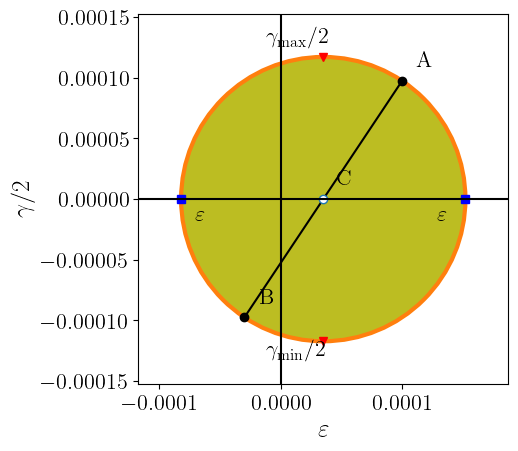


PLANO x-z:
  Deformação normal mínima:  -30.0 micro-def
  Deformação normal máxima:  100.0 micro-def
  Deformação normal média :  35.0 micro-def
Deformação de corte mínima:  -65.0 micro-def
Deformação de corte máxima:  65.0 micro-def
Ponto A ( 100.0 , 0.0 )
Ponto B ( -30.0 , -0.0 )


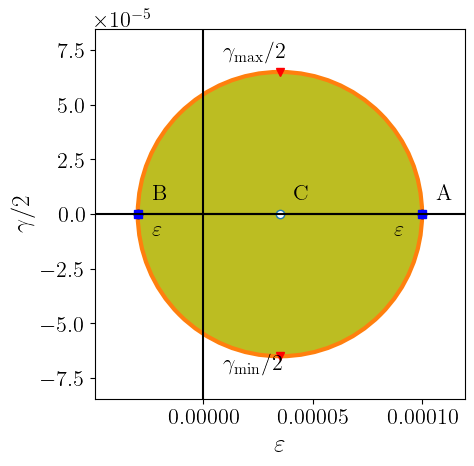

In [5]:
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=True)

def mohr(E):
    """Plot Mohr circle for a 2D tensor"""
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    Emin = center[0] - radius
    Emax = center[0] + radius

    print("  Deformação normal mínima: ", np.round(Emin*1e6,6),'micro-def')
    print("  Deformação normal máxima: ", np.round(Emax*1e6, 6),'micro-def')
    print("  Deformação normal média : ", np.round(center[0]*1e6, 6),'micro-def')
    print("Deformação de corte mínima: ", np.round(-radius*1e6, 6),'micro-def')
    print("Deformação de corte máxima: ", np.round(radius*1e6, 6),'micro-def')

    print('Ponto A (','{:.1f}'.format(E11*1e6),',','{:.1f}'.format(E12*1e6),')')
    print('Ponto B (','{:.1f}'.format(E22*1e6),',','{:.1f}'.format(-E12*1e6),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Emin - .3*radius, Emax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([E11, E22], [E12, -E12], 'ko')
    plt.plot([E11, E22], [E12, -E12], 'k')
    plt.plot(Emin, 0, 'bs')
    plt.plot(Emax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(E11 + desv, E12 + desv , 'A')
    plt.text(E22 + desv, -E12 + desv, 'B')
    plt.text(Emin + .1*radius, -0.15*radius, r'$\varepsilon$')
    plt.text(Emax - .2*radius, -0.15*radius, r'$\varepsilon$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\gamma_\mathrm{max}/2$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\gamma_\mathrm{min}/2$')
    plt.xlabel(r"$\varepsilon$", size=18)
    plt.ylabel(r"$\gamma/2$", size=18)
    #plt.xlim(limits[0,0],limits[0,1])
    #plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

print('\n================================')
print('PLANO x-y:')
print('================================')
e11 = D[0,0]; e12 = D[0,1]; e22 = D[1,1]
mohr(np.array([[e11, e12],[e12, e22]]))

print('\n================================')
print('PLANO x-z:')
print('================================')
e11 = D[0,0]; e12 = D[0,2]; e22 = D[2,2]
mohr(np.array([[e11, e12],[e12, e22]]))

### c) Calcule o tensor desviador e o tensor esférico das tensões.<a name="C"></a>

([enunciatum](#PIII72))

O tensor das tensões pode ser decomposto em:

\begin{equation*}
[\sigma] = [\sigma]_\mathrm{M} + [\sigma]_\mathrm{D}
\end{equation*}

em que $[\sigma]_\mathrm{M}$ é o tensor esférico ou hidrostático defenido por:

\begin{equation*}
[\sigma]_\mathrm{M} \equiv \frac{1}{3}\sigma_{kk}\delta_{ij} = \begin{bmatrix}
\sigma_m & 0 & 0 \\
0 & \sigma_m & 0\\
0 & 0 & \sigma_m \\
\end{bmatrix}
\end{equation*}

onde $\sigma_m = \sigma_{ii}/3 = (\sigma_{11} + \sigma_{22} +\sigma_{33})/3$ e $[\sigma]_\mathrm{D}$ é o tensor desviador dado por:

\begin{equation*}
[\sigma]_\mathrm{D} \equiv \sigma_{ij}-\frac{1}{3}\sigma_{kk}\delta_{ij} = \begin{bmatrix}
\sigma_{11}-\sigma_{m} & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22}-\sigma_{m} & \sigma_{23}\\
\sigma_{31} & \sigma_{32} & \sigma_{33}-\sigma_{m} \\
\end{bmatrix}
\end{equation*}

In [13]:
s11, s22, s33 = tt0[0,0], tt0[1,1], tt0[2,2]

sigma_m = (s11 + s22 + s33)/3
# or : sigma_m = np.trace(tt0)/3

def tensorEsferico(sm): return np.array([[sm,0,0],[0,sm,0],[0,0,sm]])

print('\nsigma_m = sigma_ii \ 3 = ',sigma_m)
tEsf = tensorEsferico(sigma_m)
print('\nTensor esférico = \n',tEsf)

tDesv = tt0 - tEsf
print('\nTensor desviador = \n',tDesv)


sigma_m = sigma_ii \ 3 =  6.666666666666667

Tensor esférico = 
 [[6.66666667 0.         0.        ]
 [0.         6.66666667 0.        ]
 [0.         0.         6.66666667]]

Tensor desviador = 
 [[13.33333333 15.          0.        ]
 [15.         -6.66666667  0.        ]
 [ 0.          0.         -6.66666667]]


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
